In [1]:
import numpy as np
import pandas as pd

import scanpy as sc
import scvelo as scv

import matplotlib.pyplot as plt
import seaborn as sns

import myutils

import random
import os

myutils.set_figure_params()
sc.settings.verbosity = 3

In [19]:
adata = sc.read_h5ad("../1_preprocess_integration/1.3.final_all_for_open_access.h5ad")
adata

AnnData object with n_obs × n_vars = 166418 × 25998
    obs: 'cell_id', 'sample', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'condition', 'leiden', 'CellType', 'condition_final'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'CellType_colors', 'batch_colors', 'condition_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [20]:
adata = adata[adata.obs["CellType"] == "Fibroblast"]
adata

View of AnnData object with n_obs × n_vars = 28409 × 25998
    obs: 'cell_id', 'sample', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'condition', 'leiden', 'CellType', 'condition_final'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'CellType_colors', 'batch_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [21]:
adata.uns['log1p']["base"] = None
sc.pp.highly_variable_genes(adata)
sc.tl.pca(adata)

extracting highly variable genes
    finished (0:00:03)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=50
    finished (0:00:03)


In [22]:
sc.external.pp.harmony_integrate(adata, 'sample')

2025-10-28 21:01:58,215 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-10-28 21:02:00,806 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-10-28 21:02:00,958 - harmonypy - INFO - Iteration 1 of 10
2025-10-28 21:02:12,327 - harmonypy - INFO - Iteration 2 of 10
2025-10-28 21:02:24,453 - harmonypy - INFO - Iteration 3 of 10
2025-10-28 21:02:35,261 - harmonypy - INFO - Converged after 3 iterations


In [23]:
sc.pp.neighbors(adata,use_rep="X_pca_harmony")
sc.tl.umap(adata)
sc.tl.leiden(adata,resolution=1.,key_added="leiden1.0")

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:04)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:17)
running Leiden clustering
    finished: found 16 clusters and added
    'leiden1.0', the cluster labels (adata.obs, categorical) (0:00:04)


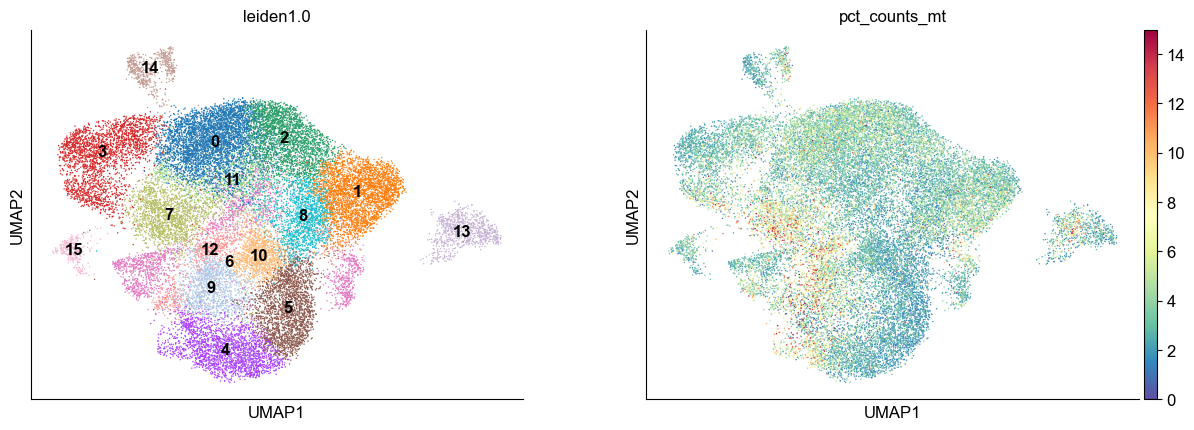

In [24]:
sc.pl.umap(adata,color=["leiden1.0","pct_counts_mt"],legend_loc="on data")

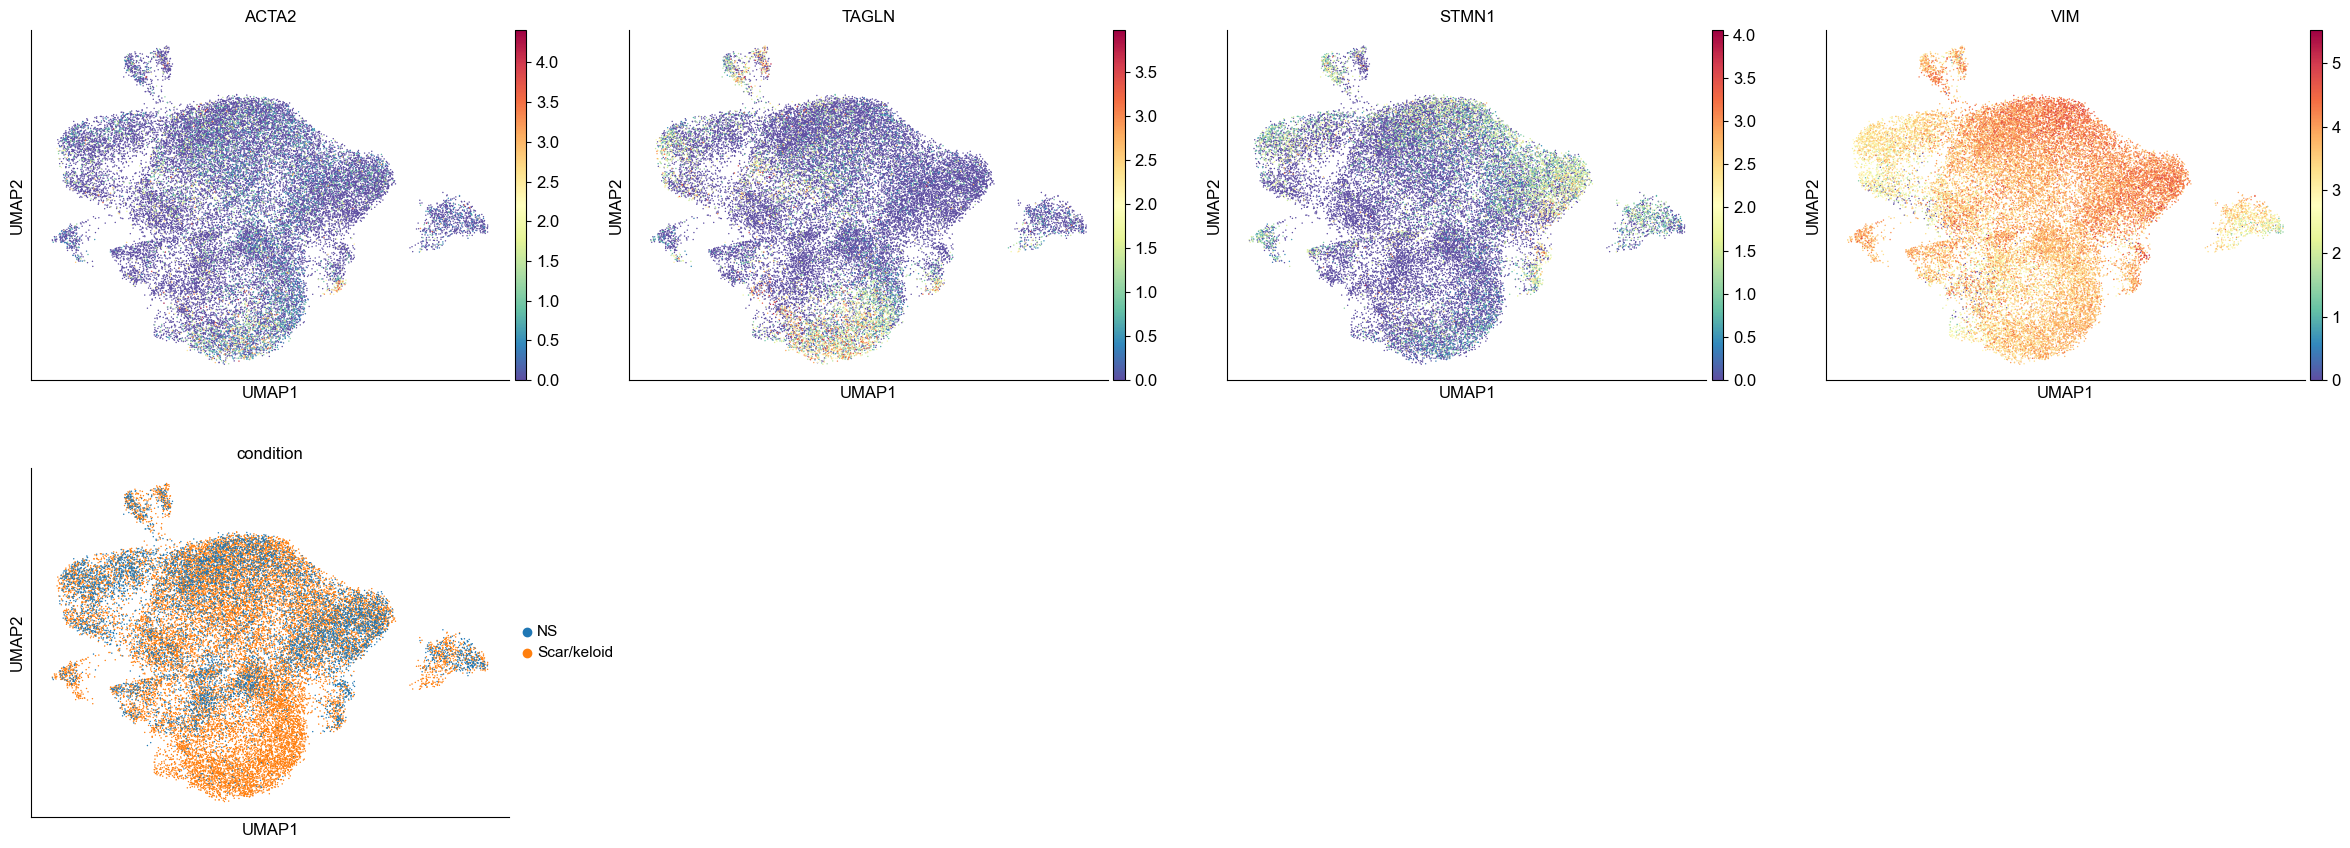

In [25]:
sc.pl.umap(adata,color=["ACTA2","TAGLN","STMN1","VIM","condition"])

In [26]:
markers = myutils.tl.scanpy_ranking_genes(adata,group_by="leiden1.0")

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:05)


In [27]:
markers[['13_names',"14_names","15_names"]].head(20)

,13_names,14_names,15_names
0,PERP,IGFBP7,CD74
1,RPLP1,NR2F2,IFI27
2,RPS19,CLDN1,HLA-E
3,DSP,APOD,AQP1
4,SFN,CYP1B1,HLA-B
5,RPS6,TGFBI,SPARCL1
6,RPS2,EGFR,A2M
7,AQP3,KLF5,TM4SF1
8,RPS18,LTBP4,B2M
9,EEF1A1,GSN,PECAM1


In [28]:
markers[['13_names',"14_names","15_names"]].tail(10)

,13_names,14_names,15_names
25988,TIMP2,MMP27,ANGPTL7
25989,S100A6,COMP,RFPL1S
25990,SERPING1,COL6A5,FOXD2
25991,PCOLCE,GPR78,AC106798.1
25992,FSTL1,C1QTNF3,SULT2B1
25993,CD63,DPT,SPANXA2-OT1
25994,MALAT1,CTHRC1,C1orf116
25995,LRP1,SFRP2,CD44-AS1
25996,DCN,CCN5,LAD1
25997,VIM,LRRC15,CLIC3


In [29]:
adata = adata[~adata.obs['leiden1.0'].isin(["15","14","13"])]
adata

View of AnnData object with n_obs × n_vars = 26710 × 25998
    obs: 'cell_id', 'sample', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'condition', 'leiden', 'CellType', 'condition_final', 'leiden1.0'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'CellType_colors', 'batch_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap', 'leiden1.0', 'leiden1.0_colors', 'condition_colors', 'rank_genes_groups'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [30]:
CellType2 = {"Fibroblast (non-myo)":[str(i) for i in range(13)],"Myofibroblast":["4","5"]}
myutils.tl.annotate_cell(adata,key_column="leiden1.0",CellType2=CellType2)

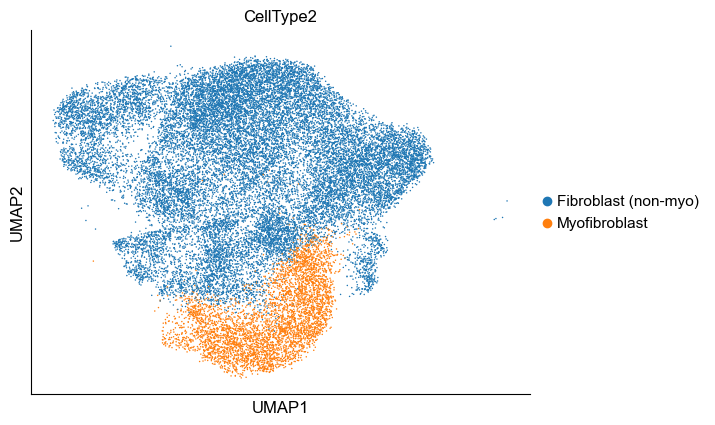

In [31]:
sc.pl.umap(adata,color="CellType2")

In [32]:
adata.write_h5ad("3.1.fibroblast_final.h5ad")

In [33]:
!conda list

# packages in environment at C:\Users\dell\.conda\envs\scanpy:
#
# Name                    Version                   Build  Channel
absl-py                   2.3.0                    pypi_0    pypi
adjusttext                1.3.0                    pypi_0    pypi
aiobotocore               2.5.4                    pypi_0    pypi
aiohappyeyeballs          2.6.1                    pypi_0    pypi
aiohttp                   3.12.4                   pypi_0    pypi
aioitertools              0.12.0                   pypi_0    pypi
aiosignal                 1.3.2                    pypi_0    pypi
anndata                   0.10.8                   pypi_0    pypi
anyio                     4.8.0                    pypi_0    pypi
argon2-cffi               23.1.0                   pypi_0    pypi
argon2-cffi-bindings      21.2.0                   pypi_0    pypi
array-api-compat          1.10.0                   pypi_0    pypi
arrow                     1.3.0                    pypi_0    pypi
asciitree 